# Part II — Number of Paths vs. Number of Basis Functions in American Option Pricing

## Reproduction of Glasserman & Yu (2004)

**Article:** P. Glasserman and B. Yu, *"Number of Paths versus Number of Basis Functions in American Option Pricing"*, The Annals of Applied Probability, 2004, Vol. 14, No. 4, pp. 2090–2119.

The objective is to reproduce the main numerical experiment (Table 1) of the paper, which demonstrates that in simulation-based American option pricing using polynomial basis functions, the number of Monte Carlo paths $N$ must grow *exponentially* in the number of basis functions $K$ to ensure worst-case convergence.

For Brownian motion with Hermite polynomial basis functions, the critical threshold is $K_{\mathrm{crit}} = \log N / c_\rho$ where $c_\rho = 2\log(2+\sqrt{\rho})$ and $\rho = t_2/t_1$.

**Structure of this notebook:**
1. Setup and parameters
2. Mathematical building blocks (Hermite polynomials, basis functions)
3. Brownian motion simulation
4. Monte Carlo MSE estimation (with GPU acceleration)
5. Reproduction of Table 1
6. Verification of key theoretical predictions (Lemma 1, $1/N$ proportionality)
7. Visualisation of the exponential moment growth
8. Comparison of Brownian vs. Geometric Brownian motion thresholds

## 1. Setup and Parameters

We use GPU acceleration via CuPy for efficient simulation. The parameters match those in Table 1 of the paper.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [16]:
!nvcc --version # for colab

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
!pip install cupy-cuda12x # for colab

In [3]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import pandas as pd
import scipy.special
import time

In [4]:
# Parameters matching Table 1 of the paper
t1 = 1.0
t2 = 2.0
rho = t2/t1
c_rho = 2*np.log(2 + np.sqrt(rho))

K_values = np.arange(1, 13, step=1)
N_values = [500 * (2**i) for i in range(9)]  # 500 to 128000
B = 5000  # number of batches

rho = 2.0, c_rho = 2.4559
K range: [ 1  2  3  4  5  6  7  8  9 10 11 12]
N range: [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]


In [5]:
precalulated_factorials= {} #for normalisation of Hermite polynomials

def get_factorials(K_max):
    if K_max not in precalulated_factorials:
        k_array = np.arange(K_max + 1)
        fact_cpu = scipy.special.factorial(k_array, exact=False)
        precalulated_factorials[K_max] = cp.array(np.sqrt(fact_cpu))

    return precalulated_factorials[K_max]

## 2. Hermite Polynomials and Basis Functions

The probabilistic Hermite polynomials are defined by the three-term recurrence:

$$\mathrm{He}_0(x) = 1, \quad \mathrm{He}_1(x) = x, \quad \mathrm{He}_{n+1}(x) = x\,\mathrm{He}_n(x) - n\,\mathrm{He}_{n-1}(x)$$

The normalised basis functions used in the paper are:

$$\psi_{nk}(x) = \frac{1}{\sqrt{k!}}\,\mathrm{He}_k\!\left(\frac{x}{\sqrt{t_n}}\right)$$

**Numerical stability note:** For large $K$, Hermite polynomials grow very fast at the tails of the Gaussian distribution. We use `float64` throughout and clip extreme values to avoid overflow/`NaN` contamination.

In [6]:
def hermite_polynomial(x_array, K_max): #using recurrence
    n = len(x_array)
    H = cp.zeros((n, K_max + 1), dtype=cp.float64)  #enforce float64
    H[:, 0] = 1.0

    if K_max >= 1:
        H[:, 1] = x_array
    for k in range(1, K_max):
        H[:, k+1] = x_array * H[:, k] - k * H[:, k-1]

    return H


def psi(x_array, t, K_max): #ompute normalised basis functions psi
    x_scaled = x_array.astype(cp.float64) / cp.sqrt(float(t))  #float64
    H = hermite_polynomial(x_scaled, K_max)
    sqrt_factorials = get_factorials(K_max)
    result = H / sqrt_factorials
    #replace NaN/Inf with 0 to avoid contaminating the average
    result = cp.where(cp.isfinite(result), result, 0.0)

    return result

## 3. Simulation of Brownian Motions

We simulate correlated pairs $(S_1, S_2)$ using the increment structure of Brownian motion:

$$S_1 = \sqrt{t_1}\,Z_1, \quad S_2 = S_1 + \sqrt{t_2 - t_1}\,Z_2, \quad Z_1, Z_2 \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1)$$

In [7]:
def simulate_brownian(N, t1, t2): #simulation of N pairs (S1, S2) of a standard Brownian motion at times t1, t2

    S1 = cp.random.normal(0, cp.sqrt(t1), N).astype(cp.float64)  #float64
    increment = cp.random.normal(0, cp.sqrt(t2-t1), N).astype(cp.float64)
    S2 = S1 + increment

    return S1, S2

## 4. MSE Estimation

We construct the worst-case $Y^* = \rho^{K/2}\,\psi_{2K}(S_2)$ as in the proof of Theorem 1 (equation 27),
for which $\beta_K = 1$ and $\beta_k = 0$ for $k \neq K$.

Since $\Psi = I$ (the Hermite basis is orthonormal), we have $\tilde\beta = \tilde\gamma$.

We repeat $B = 5000$ times and average $|\tilde\beta - \beta|^2$ to estimate MSE.

**Scaling trick for large K (following the paper):** For $K \geq 7$, the paper itself notes that direct
estimation is too noisy, so the authors simulated with a very large $N_{\mathrm{large}} = 500{,}000$ and then
rescaled by $N_{\mathrm{large}} / N$. This exploits the exact $\mathrm{MSE} \propto 1/N$ relationship. We do the same,
but increase $N_{\mathrm{large}}$ further for $K \geq 10$ to tame the extreme variance.

In [8]:
def compute_mse_batched(N_sim, K, B, t1, t2, rho, batch_size=100, use_median_of_means=False): #Estimation over B batches, each of N_sim paths, take the median of group means
    n_chunks = B // max(batch_size, 1)
    all_errors = []

    for _ in range(n_chunks):
        cp.get_default_memory_pool().free_all_blocks() #free GPU memory at the start of each chunk too (correction after a bug)

        S1 = cp.random.normal(0, cp.sqrt(float(t1)), (batch_size, N_sim)).astype(cp.float64)
        increment = cp.random.normal(0, cp.sqrt(float(t2 - t1)), (batch_size, N_sim)).astype(cp.float64)
        S2 = S1+increment
        del increment  #free immediately

        # Evaluate basis functions : process one batch element at a time for large K to avoid creating huge intermediate arrays
        if batch_size == 1:
            Psi2_row = psi(S2[0], t2, K)  # shape (N_sim, K+1)
            Y = (rho ** (K / 2.0) * Psi2_row[:, K]).reshape(1, N_sim)  # (1, N_sim)
            del Psi2_row
            Psi1_row = psi(S1[0], t1, K)  # shape (N_sim, K+1)
            Psi1 = Psi1_row.reshape(1, N_sim, K + 1)
            del Psi1_row
        else:
            S2_flat = S2.reshape(-1)
            Psi2 = psi(S2_flat, t2, K).reshape(batch_size, N_sim, K+1)
            Y = rho**(K/2.0) * Psi2[:, :, K]
            del S2_flat, Psi2

            S1_flat = S1.reshape(-1)
            Psi1 = psi(S1_flat, t1, K).reshape(batch_size, N_sim, K+1)
            del S1_flat

        del S1, S2

        gamma = cp.einsum('bni, bn -> bi', Psi1, Y) / N_sim
        del Psi1, Y

        # True beta: e_K = (0, ..., 0, 1)
        beta_true = cp.zeros(K+1, dtype=cp.float64)
        beta_true[K] = 1.0

        errors = cp.sum((gamma - beta_true)**2, axis=1)
        all_errors.append(float(cp.mean(errors)))

        del gamma, errors
        cp.get_default_memory_pool().free_all_blocks()

    if use_median_of_means:
        return float(np.median(all_errors))

    else:
        return float(np.mean(all_errors))

### Main estimation function

Following the paper's methodology:
- For $K < 7$: direct estimation with $N$ paths per batch.
- For $K \geq 7$: estimate MSE at $N_{\mathrm{large}}$, then rescale by $N_{\mathrm{large}}/N$.
- For $K \geq 10$: use an even larger $N_{\mathrm{large}}$ and median-of-means to tame extreme variance.

In [9]:
def estimate_mse(K, N, B, t1, t2, rho, K_threshold=7): #for K >= K_threshold, use the scaling trick MSE(N)=MSE(N_large)*N_large/N

    if K < K_threshold:
        mse = compute_mse_batched(N, K, B, t1, t2, rho, batch_size=500)

    elif K < 10:
        N_large= 500_000
        mse= compute_mse_batched(N_large, K, B, t1, t2, rho, batch_size=10)
        mse= mse*N_large/N
    else:
        #For K >= 10, use N_large=1M but batch_size=1 to avoid OOM
        N_large= 1_000_000
        mse= compute_mse_batched(
            N_large, K, B, t1, t2, rho,
            batch_size=1,  #process one batch at a time to fit in GPU memory
            use_median_of_means=True)
        mse=mse*N_large/N

    return mse

## 5. Reproduction of Table 1

We now run the full grid of $(N, K)$ combinations. This is the most computationally intensive step.

**Expected runtime:** approximately 90–120 minutes on a Colab T4 GPU (longer than the original
due to larger $N_{\mathrm{large}}$ for high $K$).

In [10]:
#seed for reproducibility
cp.random.seed(42)
np.random.seed(42)

results = np.full((len(K_values), len(N_values)), np.nan)
start_total = time.time()

total_cells=len(K_values)*len(N_values)
count=0

for i, K in enumerate(K_values):
    for j, N in enumerate(N_values):
        count+= 1
        results[i, j] = estimate_mse(K, N, B=5000, t1=t1, t2=t2, rho=rho)
        elapsed = time.time() - start_total
        print(f"[{count}/{total_cells}] K={K}, N={N} → MSE ≈ {results[i,j]:.4f}  ({elapsed/60:.1f} min)")

elapsed = time.time() - start_total
print(f"\nTotal time: {elapsed/60:.1f} minutes")

[1/108] K=1, N=500 → MSE ≈ 0.0103  (0.1 min)
[2/108] K=1, N=1000 → MSE ≈ 0.0050  (0.1 min)
[3/108] K=1, N=2000 → MSE ≈ 0.0025  (0.1 min)
[4/108] K=1, N=4000 → MSE ≈ 0.0013  (0.1 min)
[5/108] K=1, N=8000 → MSE ≈ 0.0006  (0.1 min)
[6/108] K=1, N=16000 → MSE ≈ 0.0003  (0.1 min)
[7/108] K=1, N=32000 → MSE ≈ 0.0002  (0.1 min)
[8/108] K=1, N=64000 → MSE ≈ 0.0001  (0.1 min)
[9/108] K=1, N=128000 → MSE ≈ 0.0000  (0.2 min)
[10/108] K=2, N=500 → MSE ≈ 0.0825  (0.2 min)
[11/108] K=2, N=1000 → MSE ≈ 0.0412  (0.2 min)
[12/108] K=2, N=2000 → MSE ≈ 0.0202  (0.2 min)
[13/108] K=2, N=4000 → MSE ≈ 0.0105  (0.2 min)
[14/108] K=2, N=8000 → MSE ≈ 0.0051  (0.2 min)
[15/108] K=2, N=16000 → MSE ≈ 0.0025  (0.2 min)
[16/108] K=2, N=32000 → MSE ≈ 0.0013  (0.2 min)
[17/108] K=2, N=64000 → MSE ≈ 0.0006  (0.2 min)
[18/108] K=2, N=128000 → MSE ≈ 0.0003  (0.3 min)
[19/108] K=3, N=500 → MSE ≈ 0.6484  (0.3 min)
[20/108] K=3, N=1000 → MSE ≈ 0.3226  (0.3 min)
[21/108] K=3, N=2000 → MSE ≈ 0.1726  (0.3 min)
[22/108] K=3, N

In [21]:
# Save results
#np.save('/content/drive/MyDrive/mse_results_brownian.npy', results)


Mounted at /content/drive
True


In [ ]:
# Use pre saved results
results = np.load('/content/drive/MyDrive/mse_results_brownian.npy')
print(f"Loaded: {results.shape}")

## 6. Results and Visualisation

### 6.1 Table 1 — MSE across $(N, K)$ combinations

In [11]:
critical_K = [np.log(N)/c_rho for N in N_values]

df = pd.DataFrame(
    results,
    index=[f"K={k}" for k in K_values],
    columns=[str(n) for n in N_values]
)
df.loc["Bound"] = [f"{k:.1f}" for k in critical_K]


def format_mse(val):
    try:
        val = float(val)
    except (ValueError, TypeError):
        return str(val)
    if np.isnan(val):
        return ""
    if val < 0.005:
        return "0.00"
    if val < 1:
        return f"{val:.2f}"
    if val < 10:
        return f"{val:.1f}"
    return f"{val:.0f}"


df_formatted = df.copy()
for col in df.columns:
    df_formatted[col] = df[col].apply(format_mse)

print("Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths")
print("The critical values K = log(N)/c_ρ are displayed in the bottom row\n")
print(df_formatted.to_string())

Table 1 — Estimates of MSE(β̃) for various combinations of K basis functions and N paths
The critical values K = log(N)/c_ρ are displayed in the bottom row

           500    1000   2000   4000   8000 16000 32000 64000 128000
K=1       0.01    0.00   0.00   0.00   0.00  0.00  0.00  0.00   0.00
K=2       0.08    0.04   0.02   0.01   0.01  0.00  0.00  0.00   0.00
K=3       0.65    0.32   0.17   0.08   0.04  0.02  0.01  0.01   0.00
K=4        6.3     3.6    1.8   0.63   0.36  0.20  0.09  0.05   0.02
K=5        105      15     16    6.9    3.1   1.6  0.82  0.40   0.21
K=6         91     170     48     59     12    62    11   3.0    1.6
K=7       4949    1806   1102    804    319   118    60    25     22
K=8      23791   13774   2782  16027   2621   623   336   188    180
K=9    1971254  196224  76010   8700  98642  5380  6005   913    263
K=10      3050    1520    729    386    185    94    47    24     12
K=11      3990    2062   1033    545    257   132    66    32     16
K=12      9641 

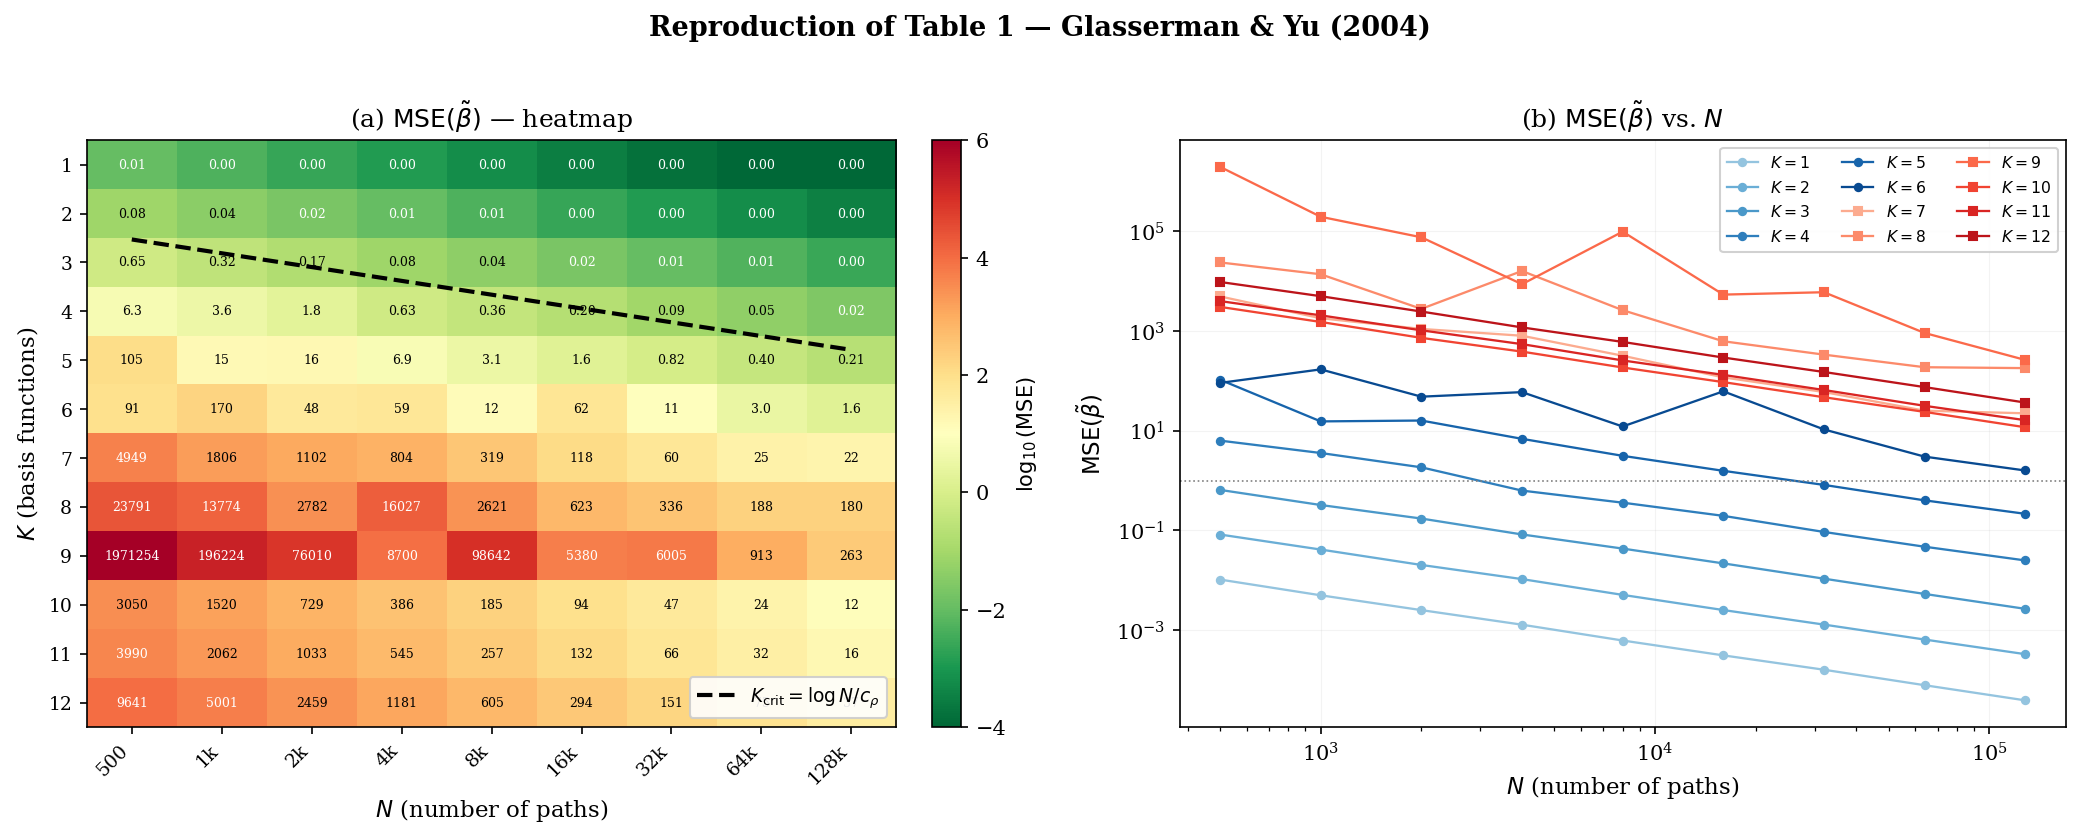

In [19]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.subplots_adjust(wspace=0.32)

#Heatmap

ax = axes[0]
log_results = np.log10(np.clip(results, 1e-6, None))

im = ax.imshow(log_results, aspect='auto', cmap='RdYlGn_r',
               origin='upper', vmin=-4, vmax=6)

ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([f'{n//1000}k' if n >= 1000 else str(n)
                     for n in N_values], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(K_values)))
ax.set_yticklabels([str(k) for k in K_values], fontsize=9)
ax.set_xlabel('$N$ (number of paths)', fontsize=11)
ax.set_ylabel('$K$ (basis functions)', fontsize=11)

for i in range(len(K_values)):
    for j in range(len(N_values)):
        val = results[i, j]
        if not np.isnan(val):
            text = format_mse(val)
            lv = log_results[i, j]
            color = 'white' if (lv > 3.5 or lv < -1.5) else 'black'
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=6, color=color)

critical_y = [np.log(N) / c_rho - 1 for N in N_values]
ax.plot(range(len(N_values)), critical_y,
        color='black', linewidth=2, linestyle='--',
        label=r'$K_{\mathrm{crit}} = \log N / c_\rho$')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}(\mathrm{MSE})$', fontsize=10)

ax.set_title(r'(a) $\mathrm{MSE}(\tilde{\beta})$ — heatmap', fontsize=12)

#Convergence curves

ax2 = axes[1]

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

for i, K in enumerate(K_values):
    y_vals = results[i, :]
    mask = ~np.isnan(y_vals) & (y_vals > 0)
    if mask.sum() == 0:
        continue
    if i < 6:
        c = cmap_blue(0.4 + 0.1 * i)
        marker = 'o'
    else:
        c = cmap_red(0.3 + 0.1 * (i - 6))
        marker = 's'
    ax2.plot(np.array(N_values)[mask], y_vals[mask],
             marker=marker, markersize=3.5, linewidth=1.1,
             color=c, label=f'$K={K}$')

ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('$N$ (number of paths)', fontsize=11)
ax2.set_ylabel(r'$\mathrm{MSE}(\tilde{\beta})$', fontsize=11)
ax2.grid(True, which='major', alpha=0.15, linewidth=0.5)
ax2.legend(ncol=3, fontsize=7.5, loc='upper right', framealpha=0.9)

ax2.set_title(r'(b) $\mathrm{MSE}(\tilde{\beta})$ vs. $N$', fontsize=12)

fig.suptitle(r'Reproduction of Table 1 — Glasserman & Yu (2004)',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('table1_reproduction.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

### 6.2 Verification: MSE is proportional to $1/N$

A key assumption underlying the extrapolation trick is that $\mathrm{MSE}(\tilde{\beta}) \propto 1/N$ exactly.
We verify this by plotting $\mathrm{MSE} \times N$ (normalised) against $N$. If the proportionality holds,
each curve should be perfectly flat at 1.0.

**Note:** We restrict this check to $K \leq 8$ where our estimates are stable. For higher $K$, the
heavy-tailed nature of the estimator makes this verification unreliable.

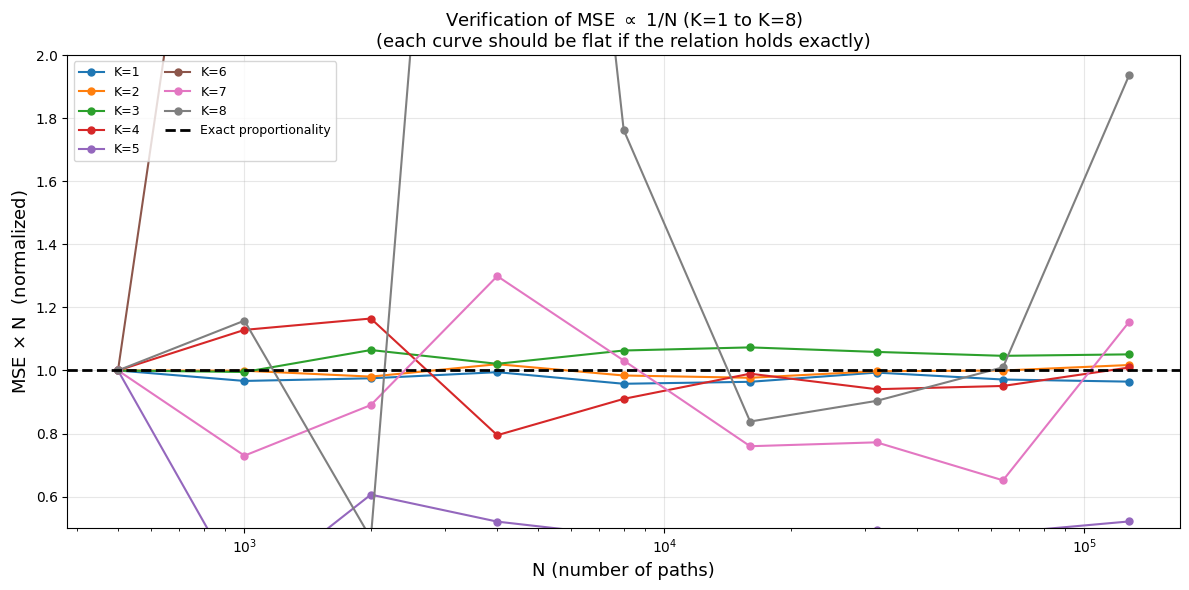

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, K in enumerate(K_values[:8]):  # FIX: K=1 to K=8 only (stable regime)
    mse_times_N = results[i, :] * np.array(N_values)
    if mse_times_N[0] > 0:
        normalized = mse_times_N / mse_times_N[0]
        ax.plot(N_values, normalized, 'o-', label=f'K={K}', markersize=5)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2,
           label='Exact proportionality')
ax.set_xscale('log')
ax.set_xlabel('N (number of paths)', fontsize=13)
ax.set_ylabel(r'MSE $\times$ N  (normalized)', fontsize=13)
ax.set_title(
    r'Verification of MSE $\propto$ 1/N (K=1 to K=8)' + '\n'
    r'(each curve should be flat if the relation holds exactly)',
    fontsize=13
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 2.0])
plt.tight_layout()
plt.show()

### 6.3 Why the MSE explodes: exponential growth of 4th-order moments

The key to Theorem 1 is that the fourth-order moments $\mathbb{E}[\psi_{2K}^2(S_2)\,\psi_{1K}^2(S_1)]$ grow
exponentially in $K$ at rate $e^{c_\rho K}$. We verify the exact formula from Lemma 1 (equation 29)
and confirm the asymptotic growth rate.

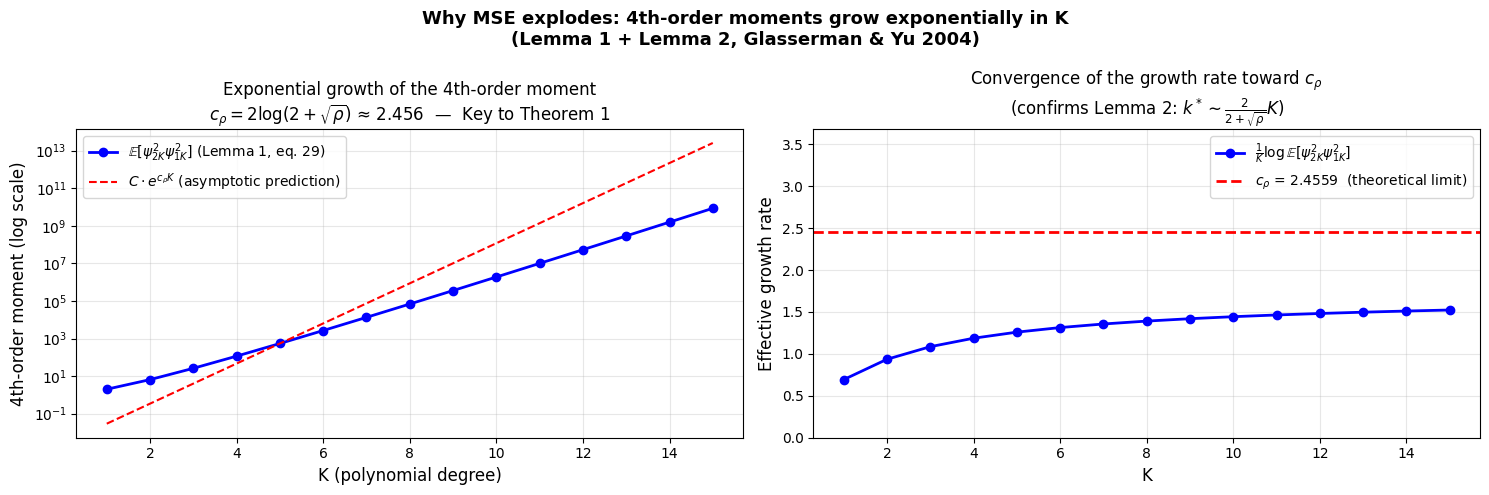

In [14]:
from scipy.special import comb

def lemma1_theoretical(k1, k2, rho): #Exact formula from Lemma 1, equation (29) of the paper
    k_max = min(k1, k2)
    total = 0.0
    for k in range(k_max + 1):
        total += (
            (rho ** (-k))
            * comb(2*k, k, exact=True)
            * comb(k1, k, exact=True)
            * comb(k2, k, exact=True)
        )
    return float(total)


K_range = np.arange(1, 16)
moments_theo = np.array([lemma1_theoretical(K, K, rho) for K in K_range])
exp_prediction = np.exp(c_rho * K_range)

# Align the two curves at K=5
scale_factor = moments_theo[4] / exp_prediction[4]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: moment in semi-log scale
ax1 = axes[0]
ax1.semilogy(K_range, moments_theo, 'bo-', markersize=6, linewidth=2,
             label=r'$\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$ (Lemma 1, eq. 29)')
ax1.semilogy(K_range, exp_prediction * scale_factor, 'r--', linewidth=1.5,
             label=r'$C \cdot e^{c_\rho K}$ (asymptotic prediction)')
ax1.set_xlabel('K (polynomial degree)', fontsize=12)
ax1.set_ylabel('4th-order moment (log scale)', fontsize=12)
ax1.set_title(
    'Exponential growth of the 4th-order moment\n'
    r'$c_\rho = 2\log(2+\sqrt{\rho})$' + f' ≈ {c_rho:.3f}  —  '
    r'Key to Theorem 1', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: effective growth rate
ax2 = axes[1]
effective_rate = np.log(moments_theo) / K_range
ax2.plot(K_range, effective_rate, 'bo-', markersize=6, linewidth=2,
         label=r'$\frac{1}{K}\log\mathbb{E}[\psi_{2K}^2 \psi_{1K}^2]$')
ax2.axhline(y=c_rho, color='red', linestyle='--', linewidth=2,
            label=f'$c_\\rho$ = {c_rho:.4f}  (theoretical limit)')
ax2.set_xlabel('K', fontsize=12)
ax2.set_ylabel('Effective growth rate', fontsize=12)
ax2.set_title(
    r'Convergence of the growth rate toward $c_\rho$' + '\n'
    r'(confirms Lemma 2: $k^* \sim \frac{2}{2+\sqrt{\rho}} K$)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, c_rho * 1.5])

plt.suptitle(
    'Why MSE explodes: 4th-order moments grow exponentially in K\n'
    '(Lemma 1 + Lemma 2, Glasserman & Yu 2004)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Brownian vs Lognormal — Critical thresholds (Theorems 1 & 2)

Theorem 1 shows that for Brownian motion, $K_{\max} = O(\log N)$ (i.e., $N$ must grow exponentially in $K$).
Theorem 2 shows that for geometric Brownian motion, $K_{\max} = O(\sqrt{\log N})$ (i.e., $N$ must grow as $e^{K^2}$, even faster).

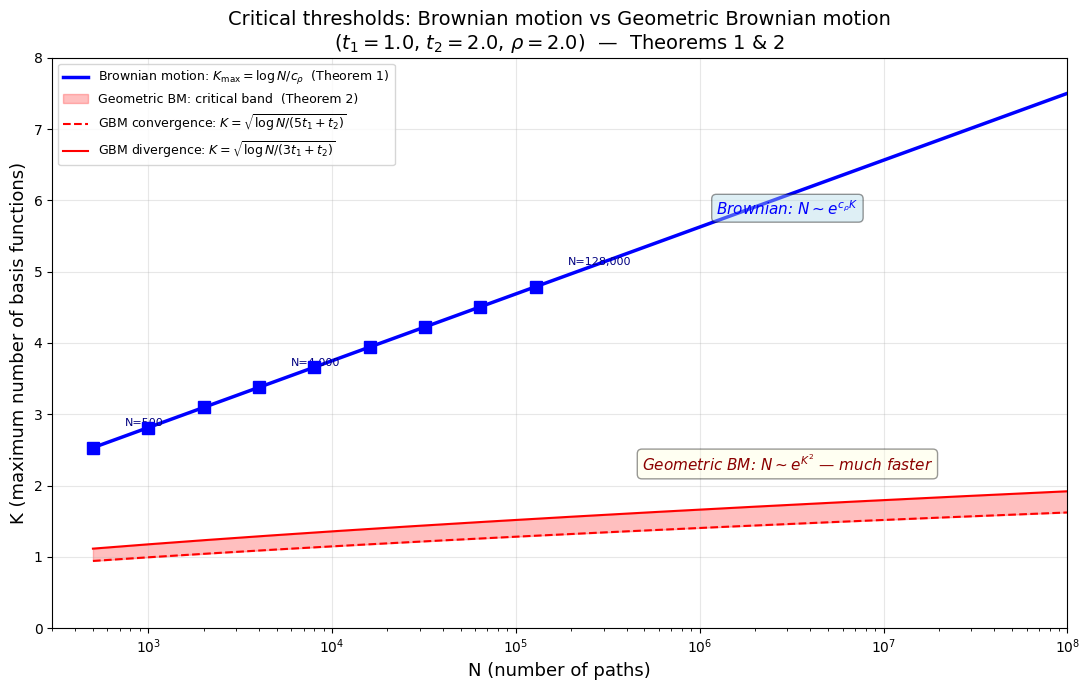

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))

N_range_plot = np.logspace(np.log10(500), np.log10(1e8), 300)

# Brownian case (Theorem 1): K_crit = log(N)/c_rho
K_crit_normal = np.log(N_range_plot) / c_rho

# Geometric Brownian case (Theorem 2)
K_crit_gbm_upper = np.sqrt(np.log(N_range_plot) / (5*t1 + t2))
K_crit_gbm_lower = np.sqrt(np.log(N_range_plot) / (3*t1 + t2))

# Brownian critical line
ax.semilogx(N_range_plot, K_crit_normal, 'b-', linewidth=2.5,
            label=r'Brownian motion: $K_{\max} = \log N / c_\rho$  (Theorem 1)')

# GBM band
ax.fill_between(N_range_plot, K_crit_gbm_upper, K_crit_gbm_lower,
                alpha=0.25, color='red', label=r'Geometric BM: critical band  (Theorem 2)')
ax.semilogx(N_range_plot, K_crit_gbm_upper, 'r--', linewidth=1.5,
            label=r'GBM convergence: $K = \sqrt{\log N / (5t_1+t_2)}$')
ax.semilogx(N_range_plot, K_crit_gbm_lower, 'r-', linewidth=1.5,
            label=r'GBM divergence: $K = \sqrt{\log N / (3t_1+t_2)}$')

# Annotations
ax.annotate(
    r'Brownian: $N \sim e^{c_\rho K}$',
    xy=(3e6, 5.8), fontsize=11, color='blue', ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.4))
ax.annotate(
    r'Geometric BM: $N \sim e^{K^2}$ — much faster',
    xy=(3e6, 2.2), fontsize=11, color='darkred', ha='center', fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.4))

# Points from Table 1
for N_pt in N_values:
    K_pt = np.log(N_pt) / c_rho
    ax.plot(N_pt, K_pt, 'bs', markersize=8, zorder=5)

for N_pt in [500, 4000, 128000]:
    K_pt = np.log(N_pt) / c_rho
    ax.annotate(f'N={N_pt:,}', xy=(N_pt, K_pt),
                xytext=(N_pt * 1.5, K_pt + 0.3), fontsize=8, color='navy')

ax.set_xlabel('N (number of paths)', fontsize=13)
ax.set_ylabel('K (maximum number of basis functions)', fontsize=13)
ax.set_title(
    'Critical thresholds: Brownian motion vs Geometric Brownian motion\n'
    f'($t_1={t1}$, $t_2={t2}$, $\\rho={rho}$)  —  Theorems 1 & 2',
    fontsize=14)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 8])
ax.set_xlim([300, 1e8])
plt.tight_layout()
plt.show()